In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df_clean_data = pd.read_csv("/content/clean_final_data.csv")
df_customers = pd.read_csv("/content/customers.csv")
df_orders = pd.read_csv("/content/orders.csv")
df_payments = pd.read_csv("/content/payments.csv")
df_products = pd.read_csv("/content/products.csv")

In [ ]:
print("Tekrar eden satır:", df_orders.duplicated().sum())

df_orders["PaymentMethod"] = df_orders["PaymentMethod"].str.strip().str.title()

print("\nPaymentMethod Dağılımı:")
print(df_orders["PaymentMethod"].value_counts())

df_orders["Status"] = df_orders["Status"].str.strip().str.title()

print("\nStatus Dağılımı:")
print(df_orders["Status"].value_counts())



Tekrar eden satır: 120

PaymentMethod Dağılımı:
PaymentMethod
Gateway       23877
Cardtocard    11981
Wallet         8804
Cash           5006
Name: count, dtype: int64

Status Dağılımı:
Status
Completed    46105
Cancelled     2477
Returned      1538
Name: count, dtype: int64


In [ ]:
sayisal_sutunlar = ["Age", "Quantity", "Discount", "UnitPrice", "Sales", "OrderValue"]
kategorik_sutunlar = ["PaymentMethod", "Status", "City", "CustomerSegment", "Category"]

print(f"Veri seti: {df_clean_data.shape[0]} satır, {df_clean_data.shape[1]} sütun")
display(df_clean_data.head())

ozet = pd.DataFrame({
    "dtype": df_clean_data.dtypes,
    "n_unique": df_clean_data.nunique(),
    "eksik_değer": df_clean_data.isnull().sum(),
    "eksik_değer_yüzdesi": (df_clean_data.isnull().mean() * 100).round(2)
})
print(ozet)
print("Tekrar eden satır sayısı:", df_clean_data.duplicated().sum())

Veri seti: 49222 satır, 17 sütun


,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,ProductName,Category,UnitPrice,Sales,OrderValue
0,500001,103695,2025-08-28,2003,4.0,10.0,Gateway,Completed,36.0,Qom,2024-03-05,Regular,USB-C Cable,Accessories,9.0,32.0,32.0
1,500002,107935,2024-05-31,2014,1.0,10.0,Wallet,Completed,49.0,Kerman,2025-06-04,Regular,Backpack,Accessories,42.0,38.0,38.0
2,500003,105141,2025-08-10,2002,1.0,20.0,CardToCard,Completed,36.0,Tehran,2025-10-19,Regular,Mechanical Keyboard,Electronics,62.0,50.0,50.0
3,500004,108780,2024-10-11,2012,1.0,10.0,Gateway,Completed,45.0,Shiraz,2023-12-07,Regular,Office Chair,Home Office,180.0,162.0,162.0
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,24.0,Karaj,2023-12-02,Regular,Phone Case,Accessories,14.0,28.0,28.0


                   dtype  n_unique  eksik_değer  eksik_değer_yüzdesi
OrderID            int64     49222            0                  0.0
CustomerID         int64      9820            0                  0.0
OrderDate         object       912            0                  0.0
ProductID          int64        20            0                  0.0
Quantity         float64         8            0                  0.0
Discount         float64         6            0                  0.0
PaymentMethod     object         4            0                  0.0
Status            object         3            0                  0.0
Age              float64        48            0                  0.0
City              object        10            0                  0.0
SignupDate        object      1094            0                  0.0
CustomerSegment   object         3            0                  0.0
ProductName       object        20            0                  0.0
Category          object         6

In [ ]:
def ortalama_guven_araligi(seri, guven=0.95):
    veri = seri.dropna()
    n = len(veri)
    ortalama = veri.mean()
    sem = stats.sem(veri)
    t_kritik = stats.t.ppf((1 + guven) / 2, df=n - 1)
    hata_payi = t_kritik * sem
    return ortalama, ortalama - hata_payi, ortalama + hata_payi

print(f"{'Değişken':20s},{'Ortalama':>12s},{'%95 Alt':>12s},{'%95 Üst':>12s}")
for degisken in sayisal_sutunlar:
    ortalama, alt, ust = ortalama_guven_araligi(df_clean_data[degisken])
    print(f"{degisken:20s},{ortalama:>12.2f},{alt:>12.2f},{ust:>12.2f}")

Değişken            ,    Ortalama,     %95 Alt,     %95 Üst
Age                 ,       41.28,       41.16,       41.40
Quantity            ,        1.88,        1.87,        1.89
Discount            ,        7.49,        7.42,        7.55
UnitPrice           ,       40.29,       39.91,       40.66
Sales               ,       69.99,       69.15,       70.82
OrderValue          ,       69.99,       69.15,       70.82


In [ ]:
betimsel = df_clean_data[sayisal_sutunlar].describe().T
betimsel["skew"] = df_clean_data[sayisal_sutunlar].skew()
betimsel["kurtosis"] = df_clean_data[sayisal_sutunlar].kurtosis()
display(betimsel.round(2))

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,49222.0,41.28,13.68,18.0,29.0,41.0,53.0,65.0,0.03,-1.16
Quantity,49222.0,1.88,1.08,-2.0,1.0,2.0,2.0,5.0,1.14,0.58
Discount,49222.0,7.49,7.75,0.0,0.0,5.0,10.0,30.0,1.05,0.68
UnitPrice,49222.0,40.29,42.61,7.0,11.0,28.0,58.0,260.0,2.67,9.36
Sales,49222.0,69.99,94.48,-170.0,17.0,38.0,84.0,1300.0,4.10,26.53
OrderValue,49222.0,69.99,94.48,-170.0,17.0,38.0,84.0,1300.0,4.10,26.53


Değişken               Shapiro-Wilk p DAgostino p  Yorum
Age                            0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.
Quantity                       0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.
Discount                       0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.
UnitPrice                      0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.
Sales                          0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.
OrderValue                     0.0000           0.0000  Normal dağılım varsayımı sağlanmamaktadır.


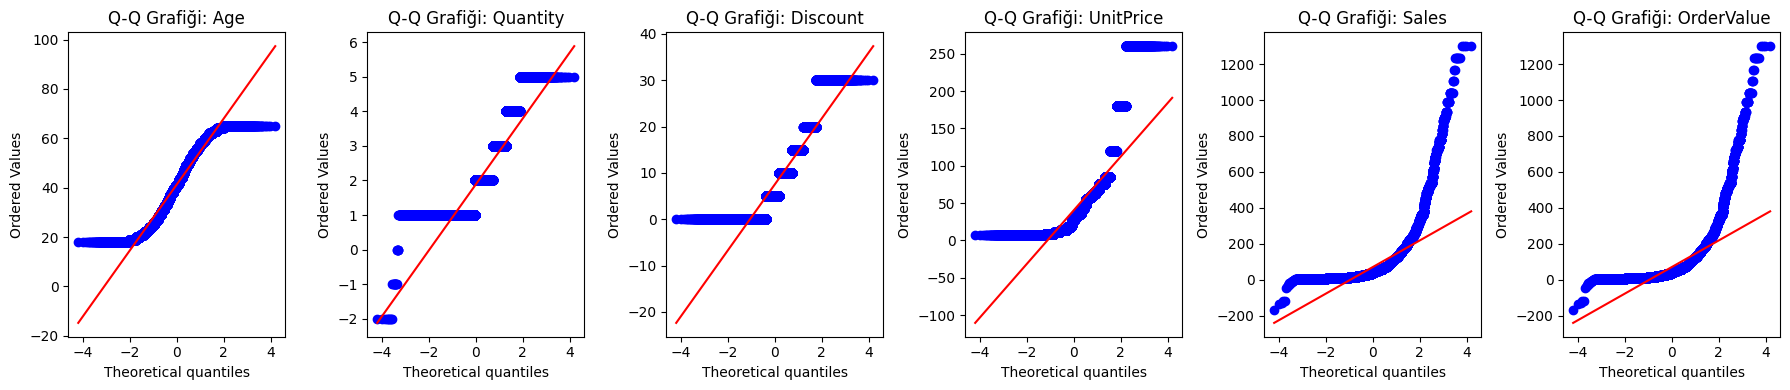

In [ ]:
print(f"{'Değişken':20s} {'Shapiro-Wilk p':>16s} {'DAgostino p'}  Yorum")
for col in sayisal_sutunlar:
    veri = df_clean_data[col].dropna()
    ornek = veri.sample(min(len(veri), 5000), random_state=0)
    sw_stat, sw_p = stats.shapiro(ornek)
    da_stat, da_p = stats.normaltest(veri)
    yorum = "Normal dağılım varsayımı sağlanmaktadır." if sw_p > 0.05 else "Normal dağılım varsayımı sağlanmamaktadır."
    print(f"{col:20s} {sw_p:>16.4f} {da_p:>16.4f}  {yorum}")

fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(18, 4))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df_clean_data[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()

In [ ]:
status_gruplari = df_clean_data["Status"].dropna().unique()
grup0 = df_clean_data.loc[df_clean_data["Status"] == status_gruplari[0], "OrderValue"].dropna()
grup1 = df_clean_data.loc[df_clean_data["Status"] == status_gruplari[1], "OrderValue"].dropna()

levene_stat, levene_p = stats.levene(grup0, grup1)
print("Varyanslar homojendir." if levene_p > 0.05 else "Varyanslar homojen değildir.")
_, p0 = stats.shapiro(grup0.sample(min(len(grup0), 5000), random_state=0))
_, p1 = stats.shapiro(grup1.sample(min(len(grup1), 5000), random_state=0))
print(f"Grup normallik p değerleri: {status_gruplari[0]} -> {p0:.4f}, {status_gruplari[1]} -> {p1:.4f}")

Varyanslar homojendir.
Grup normallik p değerleri: Completed -> 0.0000, Returned -> 0.0000


In [ ]:
musteri_gruplari = df_clean_data["CustomerSegment"].dropna().unique()
grup0 = df_clean_data.loc[df_clean_data["CustomerSegment"] == musteri_gruplari[0], "OrderValue"].dropna()
grup1 = df_clean_data.loc[df_clean_data["CustomerSegment"] == musteri_gruplari[1], "OrderValue"].dropna()
grup2 = df_clean_data.loc[df_clean_data["CustomerSegment"] == musteri_gruplari[2], "OrderValue"].dropna()

levene_stat, levene_p = stats.levene(grup0, grup1, grup2)
print("Varyanslar homojendir." if levene_p > 0.05 else "Varyanslar homojen değildir.")
_, p0 = stats.shapiro(grup0.sample(min(len(grup0), 5000), random_state=0))
_, p1 = stats.shapiro(grup1.sample(min(len(grup1), 5000), random_state=0))
_, p2 = stats.shapiro(grup2.sample(min(len(grup2), 5000), random_state=0))
print(f"Grup normallik p değerleri: {status_gruplari[0]} -> {p0:.4f}, {status_gruplari[1]} -> {p1:.4f}")

Varyanslar homojendir.
Grup normallik p değerleri: Completed -> 0.0000, Returned -> 0.0000


In [ ]:
gruplar = [g["OrderValue"].dropna().values for _, g in df_clean_data.groupby("CustomerSegment")]

f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p = stats.kruskal(*gruplar)

print(f"Tek Yönlü ANOVA: F={f_stat:.3f}, p={anova_p:.4f}")
print(f"Kruskal-Wallis: H={h_stat:.3f}, p={kw_p:.4f}")

genel_ortalama = df_clean_data["OrderValue"].mean()
ss_between = sum(len(g) * (g.mean() - genel_ortalama)**2 for g in gruplar if len(g) > 0)
ss_total = sum((df_clean_data["OrderValue"].dropna() - genel_ortalama)**2)
eta_kare = ss_between / ss_total
print(f"Eta Kare: {eta_kare:.4f} (0.01 küçük, 0.06 orta, 0.14 büyük etki)")

valid_idx = df_clean_data["OrderValue"].notna() & df_clean_data["CustomerSegment"].notna()
tukey = pairwise_tukeyhsd(
    endog=df_clean_data.loc[valid_idx, "OrderValue"],
    groups=df_clean_data.loc[valid_idx, "CustomerSegment"],
    alpha=0.05
    )
print(tukey)

Tek Yönlü ANOVA: F=0.618, p=0.5389
Kruskal-Wallis: H=0.863, p=0.6494
Eta Kare: 0.0000 (0.01 küçük, 0.06 orta, 0.14 büyük etki)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
    New Regular   0.0234 0.9996  -2.138 2.1848  False
    New     VIP  -1.5712  0.562 -5.1691 2.0267  False
Regular     VIP  -1.5946 0.5234 -5.0393 1.8502  False
-----------------------------------------------------


In [ ]:
def cramers_v(x, y):
    tablo = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tablo)[0]
    n = tablo.sum().sum()
    k = min(tablo.shape) - 1
    if n * k == 0:
        return 0.0
    return np.sqrt(chi2 / (n * k))

capraz = pd.crosstab(df_clean_data["CustomerSegment"], df_clean_data["PaymentMethod"])
chi2, p, dof, beklenen = stats.chi2_contingency(capraz)
v = cramers_v(df_clean_data["CustomerSegment"], df_clean_data["PaymentMethod"])
print(f"Chi2={chi2:.4f}, p={p:.4f}, V={v:.4f}")
print("\nÇapraz Tablo:")
display(capraz)

Chi2=2.5498, p=0.8629, V=0.0051

Çapraz Tablo:


PaymentMethod,CardToCard,Cash,Gateway,Wallet
CustomerSegment,,,,
New,4045,1692,8344,2975
Regular,6508,2744,13203,4841
VIP,1191,487,2347,845


--- Pearson Korelasyon Katsayıları ---


,Age,Quantity,Discount,UnitPrice,Sales,OrderValue
Age,1.000000,-0.002204,0.003098,0.002204,-0.001692,-0.001692
Quantity,-0.002204,1.000000,0.001848,-0.002164,0.420637,0.420637
Discount,0.003098,0.001848,1.000000,0.006917,-0.053738,-0.053738
UnitPrice,0.002204,-0.002164,0.006917,1.000000,0.782302,0.782302
Sales,-0.001692,0.420637,-0.053738,0.782302,1.000000,1.000000
OrderValue,-0.001692,0.420637,-0.053738,0.782302,1.000000,1.000000



--- Pearson P Değerleri ---


,Age,Quantity,Discount,UnitPrice,Sales,OrderValue
Age,0.0000,0.6249,0.4919,0.6249,0.7073,0.7073
Quantity,0.6249,0.0000,0.6819,0.6311,0.0000,0.0000
Discount,0.4919,0.6819,0.0000,0.1249,0.0000,0.0000
UnitPrice,0.6249,0.6311,0.1249,0.0000,0.0000,0.0000
Sales,0.7073,0.0000,0.0000,0.0000,0.0000,0.0000
OrderValue,0.7073,0.0000,0.0000,0.0000,0.0000,0.0000


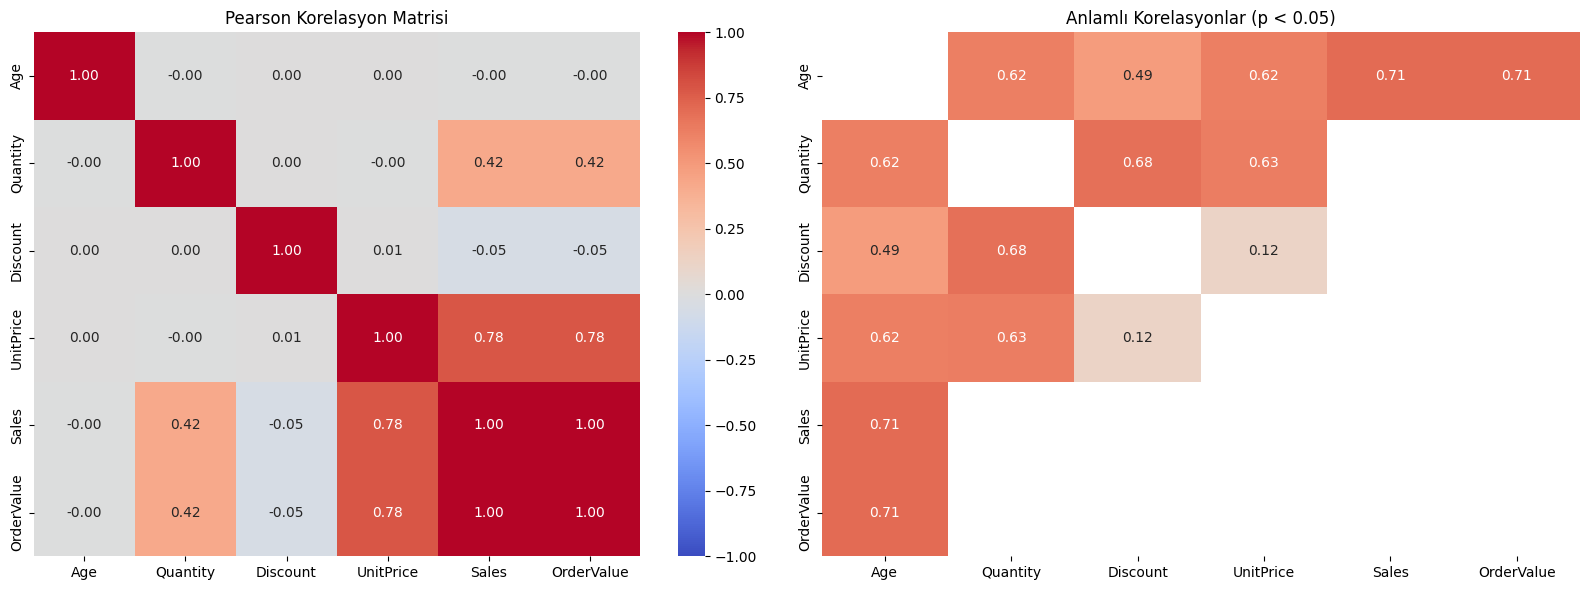

In [ ]:
def korelasyon_p_matrisi(veri, yontem="pearson"):
  sutunlar = veri.columns
  kat = pd.DataFrame(np.ones((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
  pval = pd.DataFrame(np.zeros((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
  for i in sutunlar:
    for j in sutunlar:
      if i == j:
        kat.loc[i, j] = 1.0
        pval.loc[i, j] = 0.0
        continue
      ortak = veri[[i, j]].dropna()
      x_seri, y_seri = ortak.iloc[:, 0], ortak.iloc[:, 1]
      if yontem == "pearson":
        r, p = stats.pearsonr(x_seri, y_seri)
      else:
        r, p = stats.spearmanr(x_seri, y_seri)
      kat.loc[i, j] = float(r)
      pval.loc[i, j] = float(p)
  return kat, pval

aktif_sayisal = [col for col in sayisal_sutunlar if col in df_clean_data.columns]
pearson_r, pearson_p = korelasyon_p_matrisi(df_clean_data[sayisal_sutunlar], "pearson")
print("--- Pearson Korelasyon Katsayıları ---")
display(pearson_r)
print("\n--- Pearson P Değerleri ---")
display(pearson_p.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson_r, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Korelasyon Matrisi")

anlamli_maske = pearson_p > 0.05
sns.heatmap(pearson_p, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, mask=~anlamli_maske, ax=axes[1], cbar=False)
axes[1].set_title("Anlamlı Korelasyonlar (p < 0.05)")
plt.tight_layout()
plt.show()

In [ ]:
X_vif = df_clean_data[["Age", "Discount", "UnitPrice", "Quantity"]].dropna()
X_vif = sm.add_constant(X_vif)
vif_tablosu = pd.DataFrame({
    "Değişken": X_vif.columns,
    "VIF": [VIF(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_tablosu)

    Değişken       VIF
0      const  1.000000
1        Age  1.000019
2   Discount  1.000061
3  UnitPrice  1.000057
4   Quantity  1.000013


In [ ]:
model_verisi = df_clean_data[["OrderValue", "UnitPrice", "Quantity"]].dropna()
model_verisi = sm.add_constant(model_verisi)
model = smf.ols(formula="OrderValue ~ UnitPrice + Quantity", data=model_verisi)
sonuc = model.fit()
print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:             OrderValue   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                 9.278e+04
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:17:26   Log-Likelihood:            -2.5527e+05
No. Observations:               49222   AIC:                         5.106e+05
Df Residuals:                   49219   BIC:                         5.106e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -69.5473      0.433   -160.456      0.0

In [ ]:
pca_verisi = df_clean_data[aktif_sayisal].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_verisi)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
aciklanan_varyans = pca.explained_variance_ratio_
print("Açıklanan Varyans Oranları:", aciklanan_varyans)

Açıklanan Varyans Oranları: [0.47554955 0.16769223 0.16660802 0.166145   0.0240052  0.        ]
